In [ ]:
!wget "https://fem-on-colab.github.io/releases/fenicsx-install-development-real.sh" -O "/tmp/fenicsx-install.sh" && bash "/tmp/fenicsx-install.sh"
!wget "https://fem-on-colab.github.io/releases/gmsh-install.sh" -O "/tmp/gmsh-install.sh" && bash "/tmp/gmsh-install.sh"
!apt-get install -qq xvfb
! pip install pyvista panel -q

In [12]:
import os
import numpy as np
import ufl
import dolfinx
from dolfinx import mesh, fem, io, plot
from dolfinx.fem import (Expression, Function, functionspace,
                         assemble_scalar, dirichletbc, form, locate_dofs_topological)
from mpi4py import MPI
from petsc4py import PETSc
import pyvista as pv
import dolfinx.fem.petsc
#from dolfinx.fem import project


# clears the terminal and prints dolfinx version
#os.system('clear')
# prints dolfinx version
print(f"DOLFINx version: {dolfinx.__version__}")

# no of elements in each direction
NElem   = 3
xmin = 0
ymin = 0
xmax = np.pi
ymax = np.pi
A = 1
B = 1

def calc_error_H1(uh, u_ex1, degree_raise=3):
    # Create higher order function space
    degree = uh.function_space.ufl_element().degree
    family = uh.function_space.ufl_element().family_name
    mesh = uh.function_space.mesh
    W = fem.functionspace(mesh, ("Discontinuous Lagrange", degree + degree_raise))
    # Interpolate approximate solution
    u_W = fem.Function(W)
    u_W.interpolate(uh)

    # Interpolate exact solution, special handling if exact solution
    # is a ufl expression or a python lambda function
    u_ex_W = fem.Function(W)
    if isinstance(u_ex1, ufl.core.expr.Expr):
        u_expr = fem.Expression(u_ex1, W.element.interpolation_points())
        u_ex_W.interpolate(u_expr)
    else:
        u_ex_W.interpolate(u_ex1)

    # Compute the error in the higher order function space
    e_W = fem.Function(W)
    e_W.x.array[:] = u_W.x.array - u_ex_W.x.array

    # Integrate the error
    error = fem.form( (ufl.inner(e_W, e_W) + ufl.inner(ufl.grad(e_W), ufl.grad(e_W)) ) * ufl.dx)
    error_local = fem.assemble_scalar(error)
    error_global = mesh.comm.allreduce(error_local, op=MPI.SUM)
    return np.sqrt(error_global)

def calc_error_L2(uh, u_ex, degree_raise=3):
    # Create higher order function space
    degree = uh.function_space.ufl_element().degree
    family = uh.function_space.ufl_element().family_name
    mesh = uh.function_space.mesh
    W = fem.functionspace(mesh, (family, degree + degree_raise))
    # Interpolate approximate solution
    u_W = Function(W)
    u_W.interpolate(uh)

    # Interpolate exact solution, special handling if exact solution
    # is a ufl expression or a python lambda function
    u_ex_W = Function(W)
    if isinstance(u_ex, ufl.core.expr.Expr):
        u_expr = Expression(u_ex, W.element.interpolation_points())
        u_ex_W.interpolate(u_expr)
    else:
        u_ex_W.interpolate(u_ex)

    # Compute the error in the higher order function space
    e_W = Function(W)
    e_W.x.array[:] = u_W.x.array - u_ex_W.x.array

    # Integrate the error
    error = form(ufl.inner(e_W, e_W) * ufl.dx)
    error_local = assemble_scalar(error)
    error_global = mesh.comm.allreduce(error_local, op=MPI.SUM)
    return np.sqrt(error_global)

def solve_fem_problem(NElem, xmin, ymin, xmax, ymax, A = 1, B = 1, visualize = True, plot_size = (1000, 350)):
    # create a unit square with 8x8 elements with quad elements and use first order shape function
    domain  = mesh.create_rectangle(MPI.COMM_WORLD, ((xmin, ymin), (xmax, ymax)), (NElem,NElem), mesh.CellType.quadrilateral)
    V       = fem.functionspace(domain,("Lagrange", 1))
    #V       = fem.functionspace(domain,("Lagrange",1))

    ## define trial and test functions
    u       = ufl.TrialFunction(V)
    v       = ufl.TestFunction(V)

    # source term of the poisson equation
    #f       = fem.Constant(domain, PETSc.ScalarType(-6))
    f       = fem.Function(V)
    f.interpolate(lambda x: (A**2 + B**2)*np.sin(A*x[0])*np.cos(B*x[1]))

    ## applying boundary conditions
    uD      = fem.Function(V)
    #uD.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)
    uD.interpolate(lambda x: np.sin(A*x[0])*np.cos(B*x[1]))
    tdim    = domain.topology.dim
    fdim    = tdim-1
    domain.topology.create_connectivity(fdim, tdim)
    boundary_facets = mesh.exterior_facet_indices(domain.topology)
    boundary_dofs   = fem.locate_dofs_topological(V, fdim, boundary_facets)
    bc      = fem.dirichletbc(uD, boundary_dofs)

    # bilinear form
    a       = ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    L       = f * v * ufl.dx

    # set PETSc solver options
    sol_opts = {"ksp_type": "preonly", "pc_type": "lu"}
    # formulate the problem
    problem = fem.petsc.LinearProblem(a, L, bcs=[bc], petsc_options=sol_opts)
    # solve the problem
    uh = problem.solve()

    ## error calculation
    V2          = fem.functionspace(domain, ("Lagrange", 2))
    uex         = fem.Function(V2)
    #uex.interpolate(lambda x: 1 + x[0]**2 + 2 * x[1]**2)
    uex.interpolate(lambda x: np.sin(A*x[0])*np.cos(B*x[1]))

    #zero = fem.Function(V)
    #zero.interpolate(lambda: 0)

    def u_ex(mod):
        return lambda x: mod.sin(A * x[0]) * mod.cos(B * x[1])

    u_numpy = u_ex(np)
    #u_ex1 = u_ufl(x)

    # def zero(mod):
    #     return lambda x: 0
    # zero_numpy = zero(np)

    L2_error    = fem.form(ufl.inner(uh-uex, uh-uex) * ufl.dx)
    error_local = fem.assemble_scalar(L2_error)
    error_L2    = np.sqrt(domain.comm.allreduce(error_local, op=MPI.SUM))

    er_L2 = calc_error_L2(uh, u_numpy)

    eh = uh - uex
    error_H10 = fem.form(ufl.dot(ufl.grad(eh), ufl.grad(eh)) * ufl.dx)
    E_H10 = np.sqrt(V2.mesh.comm.allreduce(fem.assemble_scalar(error_H10), op=MPI.SUM))

    x = ufl.SpatialCoordinate(domain)
    u_exact = ufl.sin(A*x[0])*ufl.cos(B*x[1])
    error_H1 = fem.form(ufl.inner(uh-uex, uh-uex) * ufl.dx + ufl.dot(ufl.grad(uh-uex), ufl.grad(uh-uex)) * ufl.dx)
    error_h1_local = fem.assemble_scalar(error_H1)
    #inner(grad(u), grad(u))dx +  inner(u, u)dx
    error_H1 = np.sqrt(domain.comm.allreduce(error_h1_local, op=MPI.SUM))

    uex_norm_H1 = fem.form(ufl.inner(uex, uex) * ufl.dx + ufl.inner(ufl.grad(uex), ufl.grad(uex)) * ufl.dx)
    #uex_norm_H1 = fem.form(ufl.inner(ufl.grad(uex), ufl.grad(uex)) * ufl.dx)
    uex_h1_local = fem.assemble_scalar(uex_norm_H1)
    #inner(grad(u), grad(u))dx +  inner(u, u)dx
    uex_norm_H1 = np.sqrt(domain.comm.allreduce(uex_h1_local, op=MPI.SUM))

    #uex_norm_H1_2 = calc_error_H1(uex, u_numpy, degree_raise=3)
    uex_normH20_analytical = np.pi / 2 * np.sqrt(A**4 + B**4 + A**2*B**2)
    uex_normH1_analytical = np.pi / 2 * np.sqrt(A**2 + B**2 + 1)
    #error_H1 = error_H1/uex_normH20_analytical
    #er = errornorm(uh, u_numpy, "H1")
    #er_H1 = dolfinx.errornorm(uex, uh, norm_type="H1")
      # Error calculation
    #uex_expr = u_ex(domain, A, B)
    er_H1 = calc_error_H1(uh, u_numpy, degree_raise=3)
    #er_H1 = calc_error_H1(uh, u_ex(ufl), degree_raise=3)

    error_max   = np.max(np.abs(uD.x.array-uh.x.array))

    #interpolate uh to finer mesh for plotting
    uh_fine = fem.Function(V2)
    # Assuming you have already created V2 as a function space associated with some mesh
    u_topology2 = V2.mesh.topology  # Fetch the topology from the mesh associated with V2
    u_cell_types2 = V2.mesh.topology.index_map(u_topology2.dim)  # Cell type information
    u_geometry2 = V2.mesh.geometry.x  # Node coordinates for the mesh
    new_cells = V2.mesh.geometry.input_global_indices

    rmesh = V2.mesh
    rtopology = rmesh.topology
    cmap = rtopology.index_map(rtopology.dim)
    num_cells = cmap.size_local + cmap.num_ghosts
    #middle_nodes = mesh.locate_entities(rmesh,0,lambda x : np.isclose(x[0],0.5))
    rtopology.create_connectivity(0,2)
    #middle_cells = mesh.compute_incident_entities(rtopology,middle_nodes,0,rtopology.dim)
    all_cells = np.arange(num_cells,dtype=np.int32)
    nmmid_mid = fem.create_interpolation_data(V2,
                                    V,
                                    all_cells,
                                    padding=0)
    uh_fine.interpolate_nonmatching(uh, all_cells, interpolation_data=nmmid_mid)

    # print the error
    if domain.comm.rank == 0:
        print(f"Error_L2 : {error_L2:.2e}")
        print(f"Error_L2_2 : {er_L2:.2e}")
        print(f"Error_max : {error_max:.2e}")
        #print(f"H10-error: {E_H10:.2e}")
        print(f"H1-error: {error_H1:.2e}")
        print(f"H1-error2: {er_H1:.2e}")
        print(f"uex-H1: {uex_norm_H1:.2e}")
        #print(f"uex-H1_2: {uex_norm_H1_2:.2e}")
        print(f"uex-H1_analytical: {uex_normH1_analytical:.2e}")
        print(f"uex-H20_analytical: {uex_normH20_analytical:.2e}")
        #uex_norm_H1 uex_norm_analytical

    # writing output files in xdmf format
    with io.XDMFFile(domain.comm, "output.xdmf", "w") as xdmf:
        xdmf.write_mesh(domain)
        xdmf.write_function(uh)

    if (visualize):
        # 2D contour plots of the mesh and result using pyvista
        pv.start_xvfb()    # Uncomment the line on WSL
        pv.OFF_SCREEN = True
        topology, cell_types, geometry = dolfinx.plot.vtk_mesh(domain, tdim)
        grid = pv.UnstructuredGrid(topology, cell_types, geometry)

        plotter = pv.Plotter()
        plotter.add_mesh(grid,show_edges=True)
        plotter.view_xy()
        #plotter.show()
        plotter.save_graphic('mesh.pdf')

        pv.global_theme.colorbar_horizontal.position_x = 0.1
        pv.global_theme.colorbar_horizontal.position_y = 0.03
        pv.global_theme.colorbar_horizontal.width = 0.8
        pv.global_theme.font.fmt = '%.1f'
        pv.global_theme.font.family = 'arial'
        title_size = 12
        #pv.global_theme.font.title_size = 16

        u_topology, u_cell_types, u_geometry = dolfinx.plot.vtk_mesh(V)
        u_grid1 = pv.UnstructuredGrid(u_topology, u_cell_types, u_geometry)
        u_grid1.point_data["uh"] = uh.x.array.real
        u_grid1.set_active_scalars("uh")
        #u_plotter = pv.Plotter()
        u_plotter = pv.Plotter(shape=(1, 3), window_size=plot_size)

        u_plotter.subplot(0, 0)
        u_plotter.add_text("u_h", position='upper_edge', font_size = title_size)
        u_plotter.add_mesh(u_grid1,show_edges=True, cmap='jet')
        u_plotter.view_xy()

        u_plotter.subplot(0, 1)
        u_plotter.add_text("u_precise", position='upper_edge', font_size = title_size)
        u_topology2, u_cell_types2, u_geometry2 = dolfinx.plot.vtk_mesh(V2)
        u_grid2 = pv.UnstructuredGrid(u_topology2, u_cell_types2, u_geometry2)
        u_grid2.point_data["u"] = uex.x.array.real
        u_grid2.set_active_scalars("u")
        u_plotter.add_mesh(u_grid2,show_edges=True, cmap='jet')
        u_plotter.view_xy()

        u_plotter.subplot(0, 2)
        u_plotter.add_text("abs(uh-u_precise)", position = 'upper_edge', font_size = title_size)
        pv.global_theme.font.fmt = '%1.3f'
        u_grid3 = pv.UnstructuredGrid(u_topology2, u_cell_types2, u_geometry2)
        u_grid3.point_data["uh - u"] = np.abs(uex.x.array.real - uh_fine.x.array.real)
        u_grid3.set_active_scalars("uh - u")
        u_plotter.add_mesh(u_grid3, show_edges=True, cmap='jet')
        u_plotter.view_xy()

        #u_plotter.save_graphic('contour123.pdf')
        u_plotter.screenshot("contour123.png")

    return error_L2, error_max, error_H1

import matplotlib.pyplot as plt
def study_conv(xmin, xmax, ymin, ymax, A, B):
      l2_array = []
      c_array = []
      h1_array = []
      h = []
      for i in range(0, 100, 10):
        N = (i + 5) * 2
        l2, c, h1 = solve_fem_problem(N, xmin, ymin, xmax, ymax, A, B, visualize = False)
        l2_array.append(l2)
        c_array.append(c)
        h1_array.append(h1)
        h.append((xmax - xmin)/N)

      uex_normH20_analytical = np.pi / 2 * np.sqrt(A**4 + B**4 + A**2*B**2)
      y = np.sqrt(2)*uex_normH20_analytical * np.asarray(h)
      fig, axes = plt.subplots(1, 2, figsize=(10, 4))
      axes[0].plot(h, l2_array, label = 'l2')
      axes[0].plot(h, c_array, label='c')
      axes[0].plot(h, h1_array, label='h1')
      #plt.plot(h, y, '--', label='sqrt(2)h|u|2')
      axes[0].legend()
      axes[0].set_xlabel('h')
      axes[0].set_ylabel('norm')

      axes[1].plot(h, l2_array, label = 'l2')
      axes[1].plot(h, c_array, label='c')
      #plt.plot(h, y, '--', label='sqrt(2)h|u|2')
      axes[1].legend()
      axes[1].set_xlabel('h')
      axes[1].set_ylabel('norm')




DOLFINx version: 0.10.0.0


In [8]:
solve_fem_problem(77, xmin, ymin, xmax, ymax, 5, 8, visualize = False)

Error_L2 : 3.08e-02
Error_L2_2 : 3.08e-02
Error_max : 8.34e-03
H1-error: 1.28e+00
H1-error2: 1.28e+00
uex-H1: 1.49e+01
uex-H1_analytical: 1.49e+01
uex-H20_analytical: 1.25e+02


(np.float64(0.030815736049080698),
 np.float64(0.008335383969788168),
 np.float64(1.2820585006438303))

In [ ]:

A = 5
B = 8
NElem = 100
mesh1 = mesh.create_rectangle(MPI.COMM_WORLD, ((0, 0), (np.pi, np.pi)), (NElem,NElem), mesh.CellType.quadrilateral)
#x = mesh1.geometry.x
V2 = fem.functionspace(mesh1, ("CG", 2))
f  = fem.Function(V2)
f.interpolate(lambda x: np.sin(A*x[0])*np.cos(B*x[1]))
ggf = ufl.grad(ufl.grad(f))
local = fem.assemble_scalar(fem.form(ufl.inner(ggf,ggf)*ufl.dx))
H2_seminorm_of_f = np.sqrt(mesh1.comm.allreduce(local, op=MPI.SUM))
print(H2_seminorm_of_f)

Error_L2 : 3.05e-02
Error_L2_2 : 3.06e-02
Error_max : 2.76e-03
H1-error: 2.05e-01
H1-error2: 2.05e-01
uex-H1: 2.72e+00
uex-H1_analytical: 2.72e+00
uex-H20_analytical: 2.72e+00
Error_L2 : 3.43e-03
Error_L2_2 : 3.43e-03
Error_max : 3.07e-04
H1-error: 6.73e-02
H1-error2: 6.73e-02
uex-H1: 2.72e+00
uex-H1_analytical: 2.72e+00
uex-H20_analytical: 2.72e+00
Error_L2 : 1.24e-03
Error_L2_2 : 1.24e-03
Error_max : 1.11e-04
H1-error: 4.03e-02
H1-error2: 4.03e-02
uex-H1: 2.72e+00
uex-H1_analytical: 2.72e+00
uex-H20_analytical: 2.72e+00
Error_L2 : 6.32e-04
Error_L2_2 : 6.32e-04
Error_max : 5.66e-05
H1-error: 2.88e-02
H1-error2: 2.88e-02
uex-H1: 2.72e+00
uex-H1_analytical: 2.72e+00
uex-H20_analytical: 2.72e+00
Error_L2 : 3.82e-04
Error_L2_2 : 3.82e-04
Error_max : 3.42e-05
H1-error: 2.24e-02
H1-error2: 2.24e-02
uex-H1: 2.72e+00
uex-H1_analytical: 2.72e+00
uex-H20_analytical: 2.72e+00
Error_L2 : 2.56e-04
Error_L2_2 : 2.56e-04
Error_max : 2.29e-05
H1-error: 1.83e-02
H1-error2: 1.83e-02
uex-H1: 2.72e+00
u

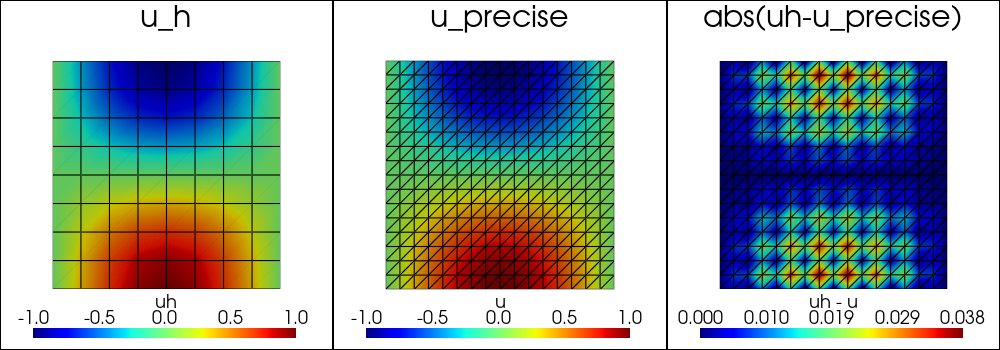

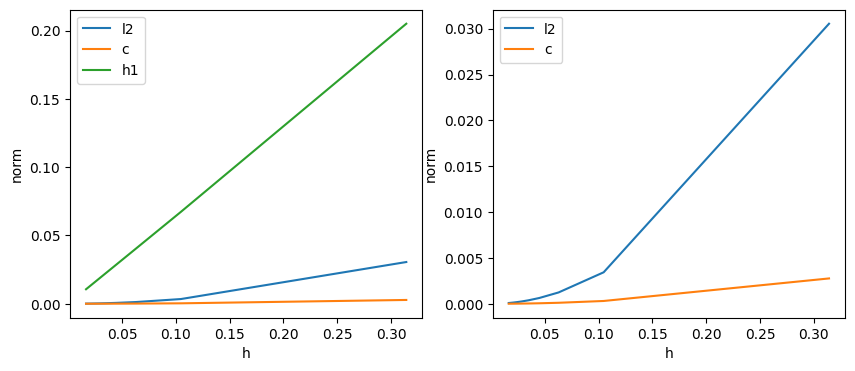

In [13]:
A = 1
B = 1
study_conv(xmin, xmax, ymin, ymax, A, B)

solve_fem_problem(8, xmin, ymin, xmax, ymax, A, B, visualize = True)
from IPython.display import Image
Image(filename='contour123.png')

Error_L2 : 1.02e+00
Error_L2_2 : 1.05e+00
Error_max : 2.75e-01
H1-error: 1.03e+01
H1-error2: 1.06e+01
uex-H1: 1.46e+01
uex-H1_analytical: 1.49e+01
uex-H20_analytical: 1.25e+02
Error_L2 : 1.92e-01
Error_L2_2 : 1.92e-01
Error_max : 5.16e-02
H1-error: 3.42e+00
H1-error2: 3.43e+00
uex-H1: 1.49e+01
uex-H1_analytical: 1.49e+01
uex-H20_analytical: 1.25e+02
Error_L2 : 7.21e-02
Error_L2_2 : 7.22e-02
Error_max : 1.97e-02
H1-error: 2.00e+00
H1-error2: 2.00e+00
uex-H1: 1.49e+01
uex-H1_analytical: 1.49e+01
uex-H20_analytical: 1.25e+02
Error_L2 : 3.72e-02
Error_L2_2 : 3.72e-02
Error_max : 1.00e-02
H1-error: 1.41e+00
H1-error2: 1.41e+00
uex-H1: 1.49e+01
uex-H1_analytical: 1.49e+01
uex-H20_analytical: 1.25e+02
Error_L2 : 2.26e-02
Error_L2_2 : 2.26e-02
Error_max : 6.14e-03
H1-error: 1.09e+00
H1-error2: 1.09e+00
uex-H1: 1.49e+01
uex-H1_analytical: 1.49e+01
uex-H20_analytical: 1.25e+02
Error_L2 : 1.52e-02
Error_L2_2 : 1.52e-02
Error_max : 4.11e-03
H1-error: 8.94e-01
H1-error2: 8.94e-01
uex-H1: 1.49e+01
u

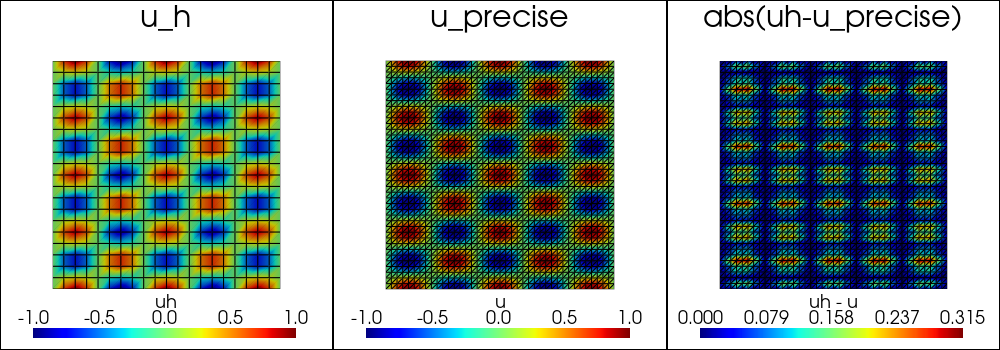

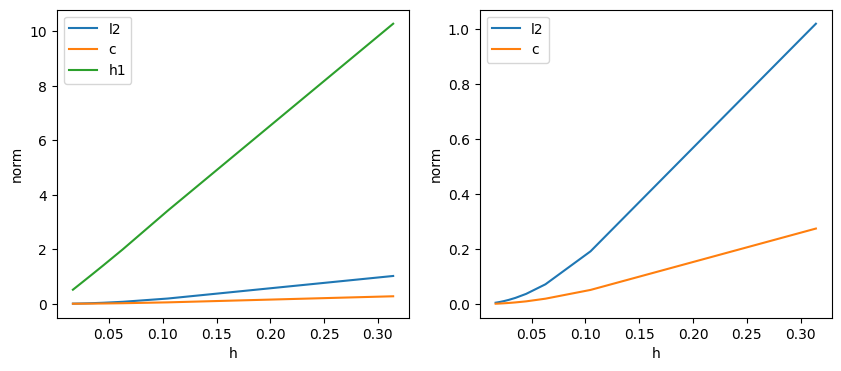

In [14]:
A = 5
B = 8
study_conv(xmin, xmax, ymin, ymax, A, B)

solve_fem_problem(20, xmin, ymin, xmax, ymax, A, B, visualize = True)
from IPython.display import Image
Image(filename='contour123.png')

Error_L2 : 1.14e+00
Error_L2_2 : 1.21e+00
Error_max : 2.92e-01
H1-error: 1.36e+01
H1-error2: 1.42e+01
uex-H1: 1.71e+01
uex-H1_analytical: 1.78e+01
uex-H20_analytical: 1.74e+02
Error_L2 : 2.52e-01
Error_L2_2 : 2.53e-01
Error_max : 5.64e-02
H1-error: 4.64e+00
H1-error2: 4.66e+00
uex-H1: 1.78e+01
uex-H1_analytical: 1.78e+01
uex-H20_analytical: 1.74e+02
Error_L2 : 9.61e-02
Error_L2_2 : 9.62e-02
Error_max : 2.15e-02
H1-error: 2.67e+00
H1-error2: 2.67e+00
uex-H1: 1.78e+01
uex-H1_analytical: 1.78e+01
uex-H20_analytical: 1.74e+02
Error_L2 : 4.98e-02
Error_L2_2 : 4.98e-02
Error_max : 1.10e-02
H1-error: 1.88e+00
H1-error2: 1.88e+00
uex-H1: 1.78e+01
uex-H1_analytical: 1.78e+01
uex-H20_analytical: 1.74e+02
Error_L2 : 3.03e-02
Error_L2_2 : 3.03e-02
Error_max : 6.75e-03
H1-error: 1.45e+00
H1-error2: 1.45e+00
uex-H1: 1.78e+01
uex-H1_analytical: 1.78e+01
uex-H20_analytical: 1.74e+02
Error_L2 : 2.04e-02
Error_L2_2 : 2.04e-02
Error_max : 4.50e-03
H1-error: 1.18e+00
H1-error2: 1.18e+00
uex-H1: 1.78e+01
u

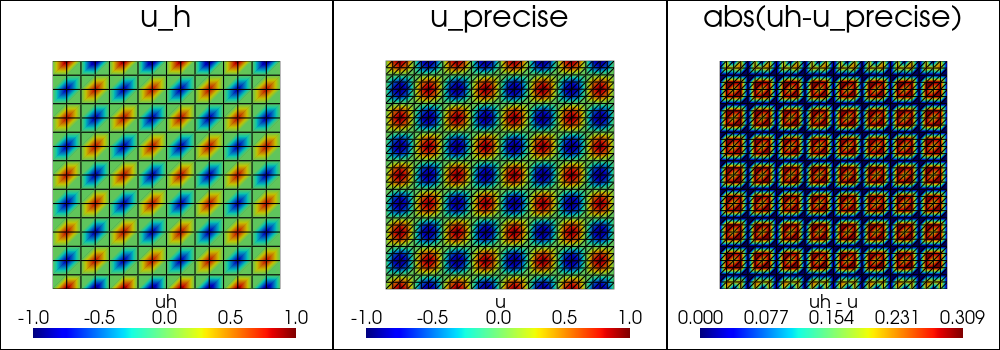

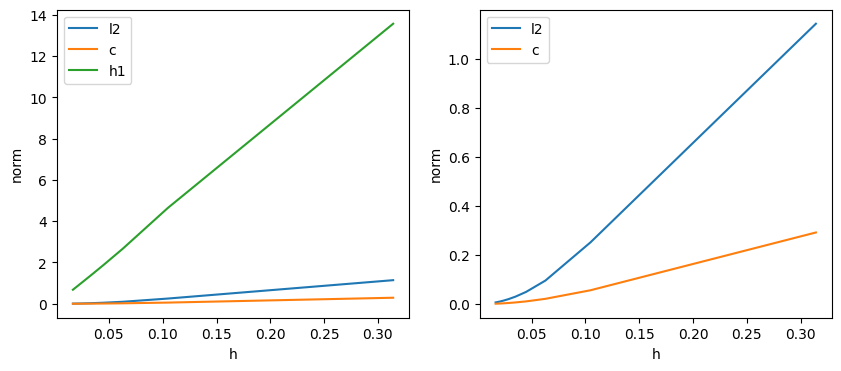

In [15]:
A = 8
B = 8
study_conv(xmin, xmax, ymin, ymax, A, B)

solve_fem_problem(16, xmin, ymin, xmax, ymax, A, B, visualize = True)
from IPython.display import Image
Image(filename='contour123.png')